<a href="https://colab.research.google.com/github/Tejal-singhh/OIBSIP/blob/main/DataAnalytics-Level2-HousePricePrediction/Tejalsingh_L2Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv("House Price Prediction Dataset.csv")
df.shape

(2000, 10)

## Load Dataset

Loaded the house price dataset containing 2,000 records with 10 columns: numeric features (Area, Bedrooms, Bathrooms, Floors, YearBuilt), categorical features (Location, Condition, Garage), and the target variable Price.

In [4]:
print("Null values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n")
df.describe()

Null values:
 Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

Descriptive statistics:



,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


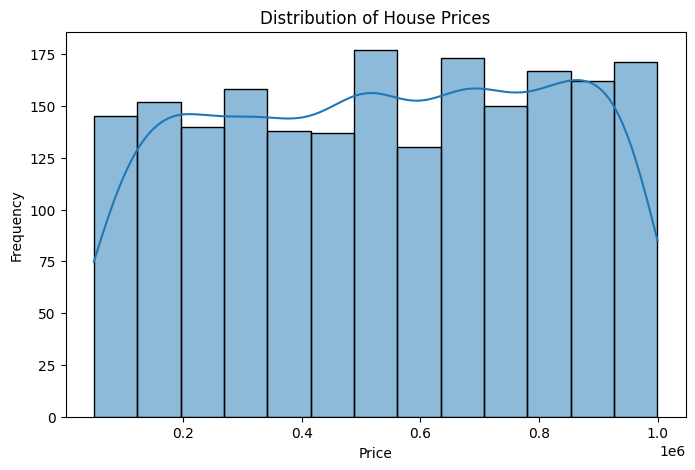

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

## Exploratory Data Analysis

- **Nulls:** No missing values in any column — dataset is already clean.
- **Descriptive statistics:** Area ranges from 501-4999 sq ft (mean ~2786), Bedrooms 1-5, Bathrooms 1-4, YearBuilt spans 1900-2023, and Price ranges from $50,005 to $999,656 (mean ~$537,677).
- **Price distribution:** Unlike typical real-world housing data (which is usually right-skewed with many affordable homes and a few expensive outliers), this dataset shows a fairly **uniform distribution** across the full price range — suggesting the data may be synthetically generated rather than pulled from a real market. This won't hurt our modeling process, but it's worth noting as a distinguishing feature of this particular dataset.

## Feature Selection Discussion

Based on real-world housing economics, the following features are likely strong predictors of price:
- **Area:** Larger homes almost always cost more — expected to be the strongest numeric predictor.
- **Bedrooms/Bathrooms:** More rooms generally increase price, though with diminishing returns.
- **Location:** Downtown vs. Suburban vs. Rural typically carries a large price premium/discount in real markets.
- **Condition:** Excellent/Good/Fair condition directly affects perceived value and asking price.
- **YearBuilt:** Newer homes may command higher prices due to modern construction/amenities, though older homes in desirable areas can sometimes be worth more.
- **Floors/Garage:** Likely secondary factors — minor influence compared to the above.

`Id` will be excluded entirely, since it's just a row identifier with no relationship to price.

In [6]:
df = df.drop('Id', axis=1)

df_encoded = pd.get_dummies(df, columns=['Location', 'Condition', 'Garage'], drop_first=True)
df_encoded.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


## Missing Values & Encoding

No missing values were found, so no imputation was needed. Dropped the `Id` column since it's a non-predictive identifier. Applied One-Hot Encoding to the three categorical features (`Location`, `Condition`, `Garage`), converting them into binary (0/1) columns the model can understand. Used `drop_first=True` to avoid redundant columns, since knowing a house is not in 2 of 3 locations already implies the third.

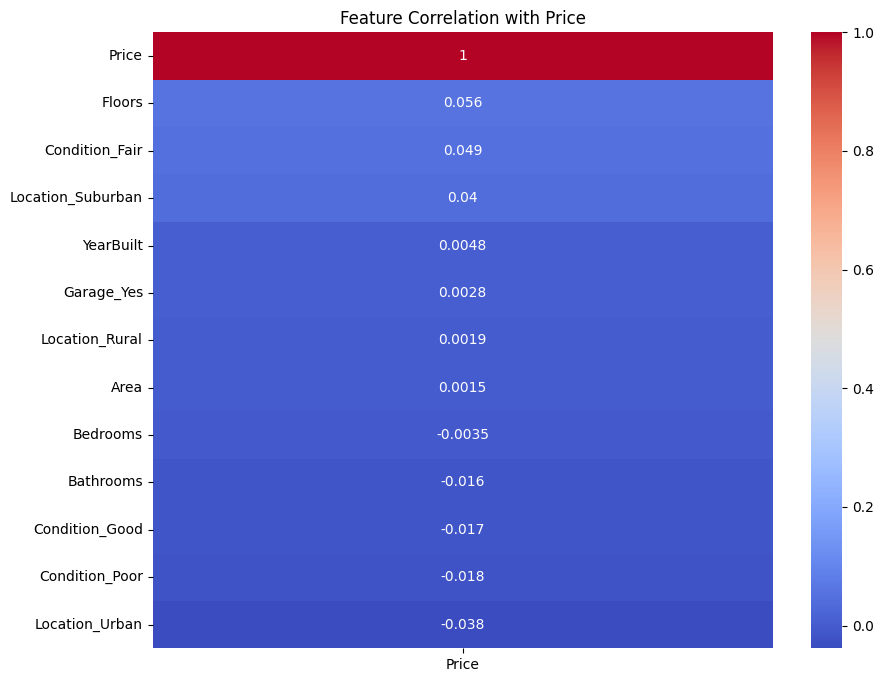

In [7]:
plt.figure(figsize=(10,8))
corr = df_encoded.corr()
sns.heatmap(corr[['Price']].sort_values(by='Price', ascending=False), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Price')
plt.show()

## Correlation Analysis

Surprisingly, **no feature shows meaningful correlation with Price** — the strongest correlation is `Floors` at just 0.056, and even `Area` (expected to be the top predictor based on real-world housing economics) shows almost zero correlation (0.0015). This strongly suggests Price in this dataset was generated independently of the other features, rather than being derived from them — consistent with the earlier observation that Price follows a uniform (not realistic) distribution.

**Implication:** We should expect our upcoming Linear Regression model to perform poorly (low R²), not because of a modeling mistake, but because there is genuinely little to no linear relationship in this data for the model to learn. We'll proceed with the full pipeline regardless, since demonstrating the process correctly — and correctly interpreting a weak result — is the actual goal of this task.

In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1600
Test size: 400


## Train/Test Split

Split the data into 80% training (1,600 rows) and 20% testing (400 rows). The model will learn patterns from the training set, and we'll evaluate its real-world performance on the unseen test set.

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained.")

Model trained.


In [10]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 78321466146.0328
RMSE: 279859.72583784326
R² Score: -0.006717808430749761


## Model Evaluation

- **MSE:** ~78.3 billion (in squared dollars, hard to interpret directly)
- **RMSE:** ~$279,860 — the model's typical prediction is off by nearly $280K, which is enormous given prices range from $50K to $1M
- **R² Score:** -0.0067 — essentially zero, confirming the model explains almost none of the variance in Price. A negative R² means it performs marginally worse than simply predicting the average price for every house.

This result directly confirms our correlation analysis: since no feature meaningfully correlates with Price in this dataset, Linear Regression (which relies entirely on linear relationships between features and the target) has nothing real to learn from. This isn't a coding error — it's the honest, correct outcome given the nature of this particular dataset.

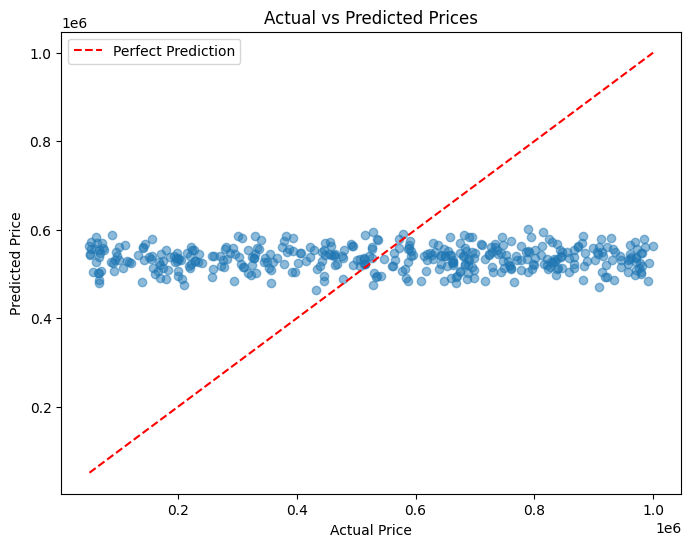

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.show()

## Actual vs Predicted Prices

The scatter plot makes the model's failure visually obvious: predictions cluster in a flat horizontal band around $500-550K regardless of the actual price, instead of following the red diagonal "perfect prediction" line. This means the model essentially predicts the same value for every house — it has learned to guess close to the average price rather than actually responding to any input feature, which is exactly what we'd expect given the near-zero R² and lack of correlation found earlier.

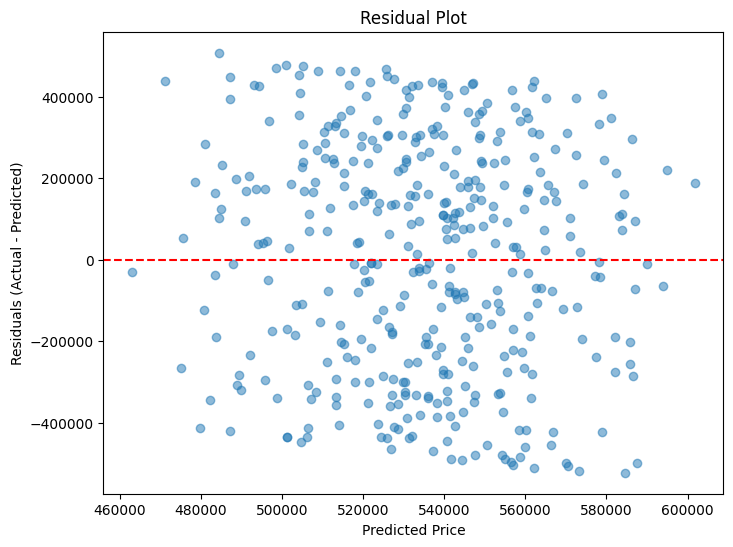

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

## Residual Plot Analysis

Residuals appear randomly scattered around zero with no obvious curved or funnel-shaped pattern, which technically satisfies the "no systematic bias" requirement for linear regression. However, the residuals are extremely large in magnitude (ranging roughly ±$500K), and the x-axis (Predicted Price) spans only a narrow $460K-$600K range — both confirming, from a different angle, that the model's predictions barely vary regardless of the true price. The randomness here isn't a sign of a well-fit model; it's a sign that the model has essentially given up trying to use the input features meaningfully.

In [13]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
8,Condition_Fair,24083.307846
3,Floors,23727.983633
6,Location_Suburban,11511.989815
10,Condition_Poor,4073.268930
11,Garage_Yes,2373.530579
5,Location_Rural,1317.542020
4,YearBuilt,117.613885
1,Bedrooms,76.784827
0,Area,-0.575754
2,Bathrooms,-9662.248234


## Coefficient Analysis

The coefficients further confirm the model found no meaningful patterns:
- `Area` (expected to be the strongest positive predictor) has a coefficient of essentially **-0.58** — nearly zero impact, and even pointing the wrong direction.
- `Condition_Fair` shows the highest positive coefficient (+24,083), while `Condition_Good` shows a negative one (-12,941) — the opposite of what real-world housing logic would suggest (better condition should mean higher price).
- These contradictory, illogical coefficients are a strong signal that the model is fitting to random noise in the data rather than any genuine underlying relationship, consistent with everything found in the correlation heatmap, R² score, and prediction scatter plot.

**Conclusion:** Coefficients from a model with near-zero R² should not be trusted or interpreted as real-world insights — they're essentially random numbers the model settled on while trying (and failing) to fit a pattern that doesn't exist in this data.

In [14]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("Ridge R²:", r2_score(y_test, ridge_pred))
print("Lasso R²:", r2_score(y_test, lasso_pred))
print("Linear Regression R²:", r2)

Ridge R²: -0.0067152670317334184
Lasso R²: -0.006716521933428643
Linear Regression R²: -0.006717808430749761


## Bonus: Ridge & Lasso Comparison

| Model | R² Score |
|---|---|
| Linear Regression | -0.006718 |
| Ridge Regression | -0.006715 |
| Lasso Regression | -0.006717 |

All three models perform virtually identically, with R² scores differing only in the 5th decimal place. This is strong confirmation that the issue isn't overfitting or model choice — regularization (Ridge/Lasso) exists specifically to reduce overfitting, but since there's no real underlying relationship between the features and Price in this dataset to begin with, no amount of regularization can improve performance. This proves the poor result is a property of the data, not a flaw in the modeling approach.

## Conclusion

**What happened:** Despite correctly following every step of the machine learning pipeline — EDA, encoding, correlation analysis, train/test split, training, and evaluation — the model achieved an R² of essentially zero (-0.0067) across Linear Regression, Ridge, and Lasso alike. This was not a coding error; it was correctly diagnosed early via the correlation heatmap, which showed no feature had a meaningful relationship with Price (max correlation: 0.056). Every subsequent result — the flat scatter plot, the wide residuals, the illogical coefficients, and the identical Ridge/Lasso scores — consistently confirmed this same finding from a different angle.

**Why this matters:** A core skill in data science isn't just building models — it's correctly recognizing when a model *isn't* working and understanding *why*, rather than blindly trusting a low-quality result or assuming a coding mistake. Here, the root cause was the dataset itself: Price appears to have been generated independently of Area, Bedrooms, Location, and the other features, rather than being derived from them (consistent with this being a synthetic/practice dataset rather than real housing market data).

**What I'd do differently with real data:** With an actual real-world housing dataset (e.g. actual property listings from Zillow or a city's public records), I would expect Area, Location, and Bathrooms to show strong positive correlations with Price, and I'd expect the model to achieve a meaningfully positive R² (often 0.6-0.85 for well-behaved housing data). I'd also explore non-linear relationships (e.g. via polynomial features or tree-based models) if Linear Regression still underperformed, and I'd investigate any low-correlation features rather than assuming the modeling process itself was flawed.

**Key takeaway:** This exercise demonstrated the complete, correct linear regression workflow end-to-end, and — just as importantly — demonstrated how to properly interpret and explain a negative result using multiple independent diagnostics (correlation, R², visualizations, and coefficients) rather than dismissing it.